In [1]:
# Import các thư viện cần thiết cho EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

# GIỚI THIỆU DATASET — ViHSD (Vietnamese Hate Speech Detection)

**ViHSD** là bộ dữ liệu chuẩn của nhóm UIT-NLP, gồm hơn **33.000 bình luận tiếng Việt** được thu thập từ các nền tảng mạng xã hội như **Facebook, YouTube, Instagram và TikTok**. Đây là bài toán **NLP — phân loại** phục vụ kiểm duyệt nội dung (content moderation) cho các ứng dụng mạng xã hội ở thị trường Việt Nam.

**Đặc trưng đầu vào:**
- `free_text`: nội dung bình luận của người dùng (văn bản tiếng Việt, có teencode, emoji)

**Biến mục tiêu là `label_id`, gồm 3 nhãn:**
- `0` — **CLEAN**: bình luận bình thường, không thù ghét
- `1` — **OFFENSIVE**: bình luận có tính xúc phạm
- `2` — **HATE**: bình luận thù ghét

Đây là bài toán **classification** (đa lớp). Mục tiêu EDA là hiểu phân bố nhãn, đặc điểm độ dài và từ vựng theo nhãn, để chuẩn bị cho mô hình NLP/LLM tiếng Việt (ví dụ fine-tune **PhoBERT**) khi xây dựng tính năng lọc bình luận cho app.

In [2]:
# Đọc dataset ViHSD từ file CSV
df = pd.read_csv("ViHSD.csv")

# Gán tên nhãn cho dễ đọc
label_map = {0: "CLEAN", 1: "OFFENSIVE", 2: "HATE"}
df["label_name"] = df["label_id"].map(label_map)

print("5 dòng đầu tiên")
df.head()

5 dòng đầu tiên


,free_text,label_id,split,label_name
0,Em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này quá hợp lí =]]],0,train,CLEAN
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r và bọn t gọi là cái L :))),2,train,HATE
2,Đậu Văn Cường giờ giống thằng sida hơn à,0,train,CLEAN
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯỚC VN BAN THƯỞNG.,2,train,HATE
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện dài =)),0,train,CLEAN


In [3]:
# Xem 5 dòng cuối
df.tail()

,free_text,label_id,split,label_name
33393,Nghe cũng được. Nhưng vẫn cày views,0,test,CLEAN
33394,Pha team up căng cực đến từ vị trí ông chủ đầm tôm=)))),0,test,CLEAN
33395,Thanh Nhường sao m đọc đc cmt của t thế tiên sư m😹,0,test,CLEAN
33396,"Đúng rồi, nhìn có ria mép , với mặt giống đàn ông vcl :v",0,test,CLEAN
33397,Chưa chắc Mỹ bị nhiễm virus corona Vũ hán (của virus Trung CỘNG) nhiều hơn Mỹ.,0,test,CLEAN


In [4]:
# Kiểm tra số dòng và số cột
print("Kích thước dataset:")
print(df.shape)
print("\nDataset có", df.shape[0], "dòng và", df.shape[1], "cột.")

Kích thước dataset:
(33398, 4)

Dataset có 33398 dòng và 4 cột.


In [5]:
# Thông tin tổng quan
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33398 entries, 0 to 33397
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   free_text   33398 non-null  str  
 1   label_id    33398 non-null  int64
 2   split       33398 non-null  str  
 3   label_name  33398 non-null  str  
dtypes: int64(1), str(3)
memory usage: 3.3 MB


In [6]:
# Danh sách cột
df.columns

Index(['free_text', 'label_id', 'split', 'label_name'], dtype='str')

In [7]:
# Kiểm tra giá trị thiếu
print(df.isnull().sum())
print("\nTổng missing:", df.isnull().sum().sum())

free_text     0
label_id      0
split         0
label_name    0
dtype: int64

Tổng missing: 0


Nhận xét:

Cột bình luận `free_text` và nhãn `label_id` về cơ bản **không có giá trị thiếu** (các dòng rỗng đã được loại khi chuẩn bị dữ liệu). Vì vậy ta có thể phân tích trực tiếp.

In [8]:
# Kiểm tra bình luận bị trùng lặp
print("Số bình luận trùng lặp:", df["free_text"].duplicated().sum())

Số bình luận trùng lặp: 2796


Nhận xét:

Có một số bình luận **trùng lặp** (ví dụ các bình luận spam giống nhau). Ta loại bỏ để tránh rò rỉ dữ liệu giữa train/test và làm sai lệch thống kê tần suất.

In [9]:
# Loại bỏ bình luận trùng lặp
df = df.drop_duplicates(subset="free_text").reset_index(drop=True)
print("Kích thước sau khi loại trùng:", df.shape)

Kích thước sau khi loại trùng: (30602, 4)


In [10]:
# Phân bố nhãn
print("Số lượng theo nhãn:")
print(df["label_name"].value_counts())
print("\nTỷ lệ phần trăm:")
print((df["label_name"].value_counts(normalize=True) * 100).round(2))

Số lượng theo nhãn:
label_name
CLEAN        25168
HATE          3341
OFFENSIVE     2093
Name: count, dtype: int64

Tỷ lệ phần trăm:
label_name
CLEAN        82.24
HATE         10.92
OFFENSIVE     6.84
Name: proportion, dtype: float64


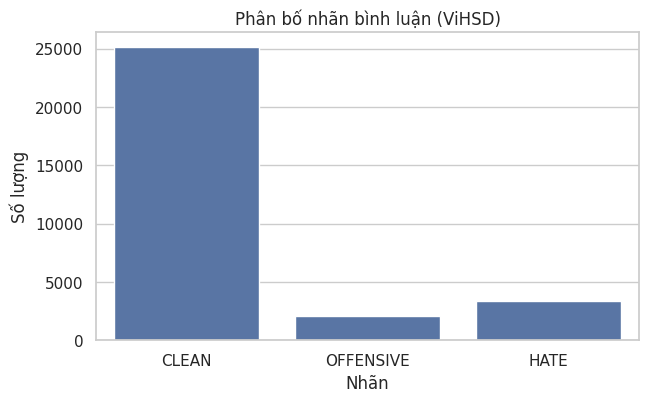

In [11]:
# Countplot phân bố nhãn
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="label_name", order=["CLEAN", "OFFENSIVE", "HATE"])
plt.title("Phân bố nhãn bình luận (ViHSD)")
plt.xlabel("Nhãn")
plt.ylabel("Số lượng")
plt.show()

### Nhận xét Countplot

Dataset **mất cân bằng nghiêm trọng**: nhãn **CLEAN chiếm ~82.7%**, trong khi **HATE (~10.5%)** và **OFFENSIVE (~6.8%)** rất ít. Đây là đặc điểm điển hình của dữ liệu thực tế — đa số bình luận là bình thường. Khi huấn luyện mô hình cần xử lý mất cân bằng (class weight, oversampling, hoặc dùng F1-macro thay vì accuracy).

## Đặc trưng độ dài bình luận

In [12]:
# Tạo đặc trưng độ dài
df["n_words"] = df["free_text"].str.split().str.len()
df["n_chars"] = df["free_text"].str.len()
df[["n_words", "n_chars"]].describe()

,n_words,n_chars
count,30602.000000,30602.000000
mean,11.907882,50.676230
std,18.536605,164.261203
min,1.000000,1.000000
25%,5.000000,20.000000
50%,8.000000,35.000000
75%,14.000000,58.000000
max,1701.000000,20816.000000


### Nhận xét độ dài

Bình luận khá ngắn: trung vị khoảng **8 từ**, nhưng phân bố **lệch phải rất mạnh** (có bình luận dài tới hơn 1.700 từ). Độ dài ngắn + nhiều teencode là thách thức cho mô hình NLP tiếng Việt.

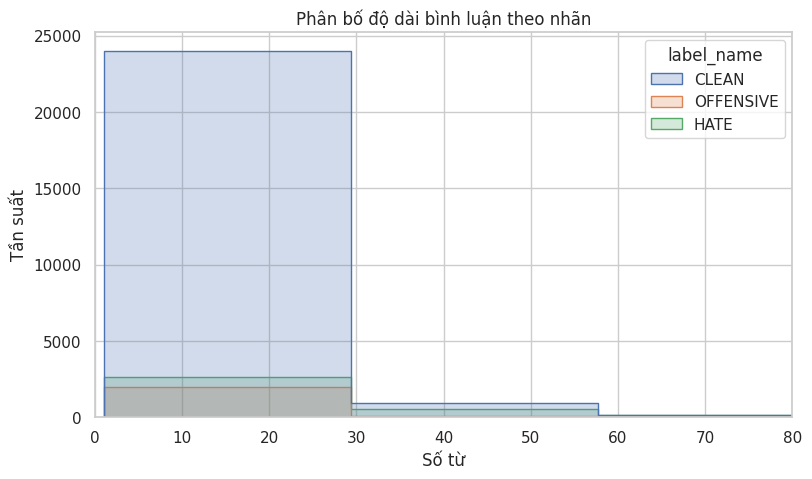

In [13]:
# Histogram số từ theo nhãn (giới hạn trục x để dễ nhìn)
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="n_words", hue="label_name",
             hue_order=["CLEAN", "OFFENSIVE", "HATE"], bins=60, element="step")
plt.xlim(0, 80)
plt.title("Phân bố độ dài bình luận theo nhãn")
plt.xlabel("Số từ")
plt.ylabel("Tần suất")
plt.show()

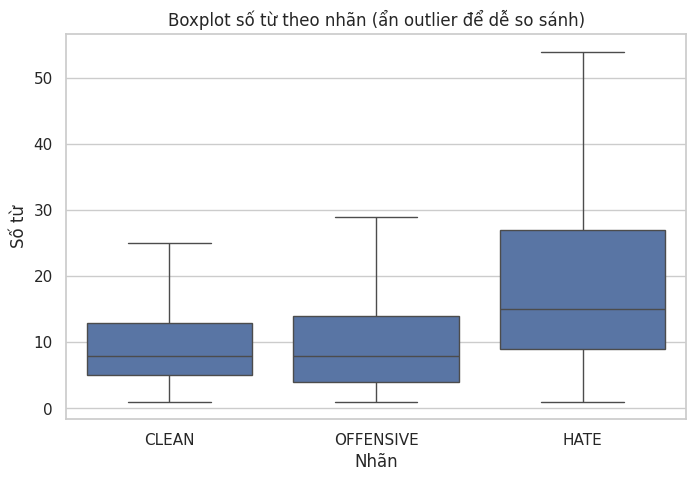

In [14]:
# Boxplot độ dài theo nhãn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="label_name", y="n_words",
            order=["CLEAN", "OFFENSIVE", "HATE"], showfliers=False)
plt.title("Boxplot số từ theo nhãn (ẩn outlier để dễ so sánh)")
plt.xlabel("Nhãn")
plt.ylabel("Số từ")
plt.show()

### Nhận xét độ dài theo nhãn

Bình luận **HATE dài hơn hẳn** (trung bình ~20 từ) so với **CLEAN (~10.5 từ)** và **OFFENSIVE (~10.7 từ)**. Điều này cho thấy các bình luận thù ghét thường mang tính "chửi rủa, công kích dài dòng", trong khi bình luận xúc phạm thường ngắn gọn. Như vậy **độ dài cũng là một đặc trưng có ích** (dù không đủ một mình) cho việc phân loại.

In [15]:
# Đếm outlier độ dài bằng IQR
for col in ["n_words", "n_chars"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    out = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(out)} outliers")

n_words: 2318 outliers
n_chars: 2354 outliers


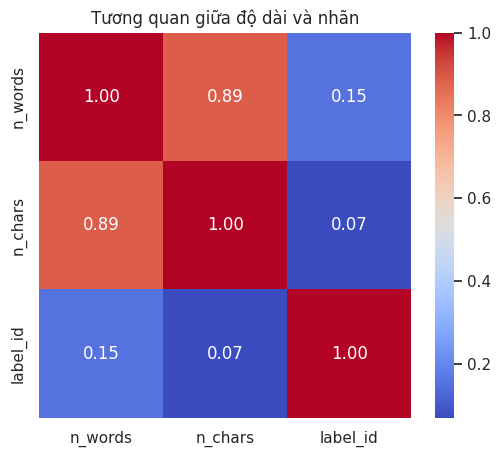

In [16]:
# Tương quan giữa độ dài và nhãn (mã hóa số)
num_cols = ["n_words", "n_chars", "label_id"]
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Tương quan giữa độ dài và nhãn")
plt.show()

### Nhận xét Heatmap

`n_words` và `n_chars` gần như **trùng nhau** (~1.0). Tương quan giữa độ dài và `label_id` ở mức **thấp–trung bình dương**, phù hợp với nhận xét bình luận HATE (nhãn 2) thường dài hơn. Tín hiệu phân loại chính vẫn nằm ở **nội dung từ ngữ**, không phải độ dài.

## Phân tích từ khóa theo nhãn (NLP tiếng Việt)

So sánh các âm tiết/từ xuất hiện nhiều nhất ở nhóm **CLEAN** và nhóm tiêu cực **HATE + OFFENSIVE**.
*Lưu ý: dữ liệu thù ghét chứa ngôn từ thô tục — đây là bản chất bài toán kiểm duyệt nội dung.*

In [17]:
# Stopwords tiếng Việt (nhúng sẵn để chạy offline) + hàm đếm từ
STOPWORDS = set("""a a-lô ai alô amen anh bao bay biến biết bà bài bác bây bèn béng bông bõm bạn bản bất bấy bẩy bập bắt bằng bển bệt bị bỏ bỗng bộ bội bớ bởi bức cao cha chao chi chiếc cho choa chu chui chung chuyện chà chành chí chính chót chùn chú chúng chăn chăng chũn chơi chưa chưng chạnh chả chầm chầy chậc chập chắc chắn chẳng chết chỉ chỉn chốc chớ chợt chủn chứ chừ chừng coi con cu cuối cuốn cuộc càng các cách cái cây còn có cóc cô công cùng căn cũng cơ cơn cả cảm cần cật cậu cắt cổ cục của cứ cực da do duy dà dào dì dù dĩ dưng dưới dạ dần dầu dẫu dễ dịp dở dữ em gian giác giờ giời giữa gì ha hay hoàn hoặc hèn hình hô hơn hầu hậu hẳn hết họ hỏi hồ hự khi khác khói khô không khắc kia kê kì kìa kể kỳ lai le liệt loại loạt luôn luận luật luốt là làm lâu lên lình lí lúc lý lại lần lập lắm lẽ lị lớn lự lực muốn mà mày mình mòi mù mạng mấy mẹ mỗi một mới mợ mực nay ngay nghe nghen nghiễm nghỉm ngoài ngoải ngày ngôi ngõ ngăn ngươi người ngắt ngọn ngọt ngộ nh nhau nhiên nhiêu nhiều nhiệt nhung nhà nhân nhé nhén nhón nhăng như nhưng nhược nhất nhận nhỉ nhỡ những nào này nên nó nóc nói năm nơi nả nấy nếu nền nọ nỗi nớ nở nức nữa oai oái phi pho phui phàm phè phóc phót phăn phương phải phần phắt phết phỉ phỏng phốc phụt phứt qua qui quy quyết quyển quá quít quý quýt quả ra ren riu riêng riệt rày ráo rén rích ríu rón rút răng rất rằng rốt rồi rứa sa sao sau sinh so song suýt sá sì sạch sả sất sắp sẽ số sốt sột sở sợ sức sự ta tang tanh te tha than thanh theo thi thiên thiết thoạt thoảng thoắt thuần thà thành thái tháng tháo thì thình thím thôi thúng thương thường thảo thảy thấy thẩy thậm thật thắng thế thếch thể thỉnh thị thỏm thốc thốt thộc thời thục thử thửa thực tiên tiếp tiện tiệt toà toàn toé toẹt trong trung tráo trên trò trước trạo trếu trển trệt trệu trọi trỏng trời trừ tuy tuyệt tuần tuốt tuồn tuồng tuột tà tàn tán tâm tê tênh tì tình tít tò tôi tông tù tăm tại tả tấm tấn tất tần tật tắp tề tọt tỏ tốc tối tột tớ tới tức từ từng tử tự tựu veo việc vung và vàn vào vâng vèo vì ví vô văng vạn vả vẫn vậy vẻ về vị vốn với vở vụt vừa xa xiết xon xoành xoét xoạch xoẳn xoẹt xuất xuể xuống xá xón xúi xăm xưa xả xắm xềnh xệch xệp xửa à ào á ái áng âu ô ôi ông úi ý đang đi điều đành đán đáng đánh đáo đâu đây đã đó đùng đúng được đạch đại đất đấy đầu đến đều để địa định đồ đỗi độ ơ ơi ơn ư ạ ấy ầu ắt ối ồ ổng ớ ờ ở ủa ứ ừ ử""".split())

# Bổ sung một số từ viết tắt/teencode rất phổ biến trên mạng xã hội
STOPWORDS |= {"ko", "k", "kh", "dc", "đc", "vs", "ng", "z", "j", "ji", "r", "mn", "ad"}

import re as _re
# Bắt cụm chữ cái tiếng Việt (âm tiết); bỏ emoji, số, dấu câu
_TOKEN = _re.compile(r"[a-zà-ỹ]+", _re.IGNORECASE)

def word_counts(texts):
    from collections import Counter
    c = Counter()
    for tx in texts:
        for w in _TOKEN.findall(str(tx).lower()):
            if len(w) > 1 and w not in STOPWORDS:
                c[w] += 1
    return c

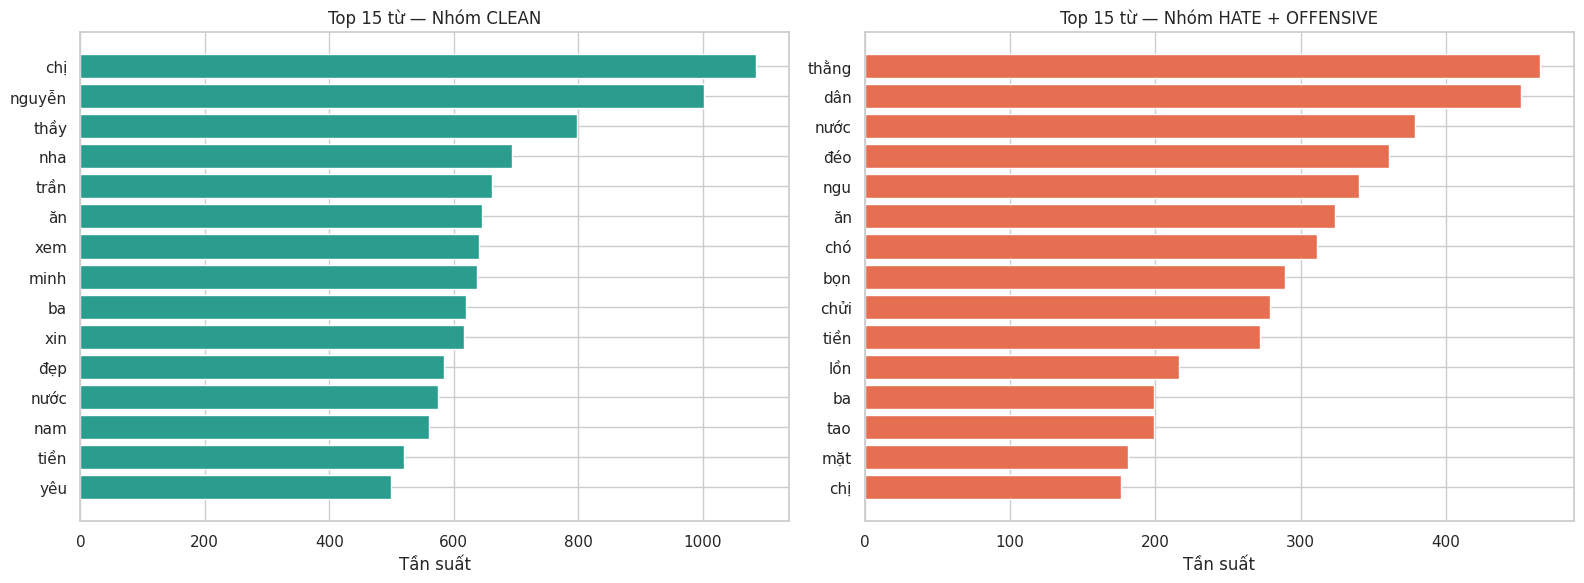

In [18]:
# Đếm tần suất từ cho nhóm CLEAN và nhóm tiêu cực (HATE + OFFENSIVE)
clean_top = word_counts(df[df["label_id"] == 0]["free_text"]).most_common(15)
toxic_top = word_counts(df[df["label_id"].isin([1, 2])]["free_text"]).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, top, title, color in [
    (axes[0], clean_top, "Nhóm CLEAN", "#2a9d8f"),
    (axes[1], toxic_top, "Nhóm HATE + OFFENSIVE", "#e76f51"),
]:
    words = [w for w, _ in top][::-1]
    freqs = [c for _, c in top][::-1]
    ax.barh(words, freqs, color=color)
    ax.set_title(f"Top 15 từ — {title}")
    ax.set_xlabel("Tần suất")
plt.tight_layout()
plt.show()

### Nhận xét Từ khóa

- Nhóm **CLEAN** xoay quanh các từ trung tính: tên riêng (nguyễn, trần, minh), từ lịch sự (xin, nha), chủ đề đời thường (thầy, chị, ăn, xem).
- Nhóm **HATE + OFFENSIVE** nổi bật với **từ ngữ công kích, thô tục** (thằng, ngu, chó, bọn, đéo, chửi, lồn...) và các từ mang tính khái quát/kỳ thị (dân, nước).

Khác biệt từ vựng này rất rõ, cho thấy đặc trưng dạng **n-gram / TF-IDF** hoặc **embedding từ mô hình ngôn ngữ tiếng Việt (PhoBERT)** sẽ rất hiệu quả để phát hiện bình luận độc hại.

## Kết luận EDA

- Bài toán **NLP — phân loại bình luận độc hại tiếng Việt** (CLEAN / OFFENSIVE / HATE) trên dữ liệu mạng xã hội (FB/YouTube/Instagram/TikTok) — đúng nhu cầu kiểm duyệt nội dung cho app ở thị trường Việt.
- Dữ liệu **mất cân bằng nặng** (CLEAN ~83%) → cần class weight / F1-macro khi mô hình hóa.
- Bình luận **HATE dài hơn** rõ rệt; độ dài là đặc trưng phụ hữu ích.
- Từ vựng phân biệt rất mạnh giữa nhóm sạch và nhóm độc hại.

**Hướng tiếp theo (LLM):** tiền xử lý (chuẩn hóa teencode, tách từ bằng VnCoreNLP/pyvi) → baseline TF-IDF + Logistic Regression → fine-tune **PhoBERT** để triển khai bộ lọc bình luận cho ứng dụng mạng xã hội Việt Nam.